In [1]:
import pandas as pd

df = pd.read_csv('../datasets/redmi6.csv', encoding='windows-1252')

In [2]:
df.sample(10)

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
207,Midil,Deva bhoi,5.0 out of 5 stars,on 24 September 2018,Others,Nice,NaN
242,Best phone forever.,Manish Singh,5.0 out of 5 stars,on 18 September 2018,Others,Best phone with face unlock full hd video reco...,20 people found this helpful
219,Look some other options guys.... It's just a c...,Shubham jaishwal,1.0 out of 5 stars,on 15 September 2018,Display,"Guys, just don't buy Redmi 6 pro for now atlea...",NaN
11,vry small size mobile,Raza ji,3.0 out of 5 stars,on 15 September 2018,Others,All ok but vry small size mobile,7 people found this helpful
210,Superb,Harsha,5.0 out of 5 stars,on 19 September 2018,Others,Good,NaN
40,Nice,Rohit Mengal,5.0 out of 5 stars,on 23 September 2018,Others,Good phone,One person found this helpful
118,Sound v acha nhi hai,Md shahab,4.0 out of 5 stars,on 23 September 2018,Camera,Front camera low hai cost jyada hair 9999 take...,NaN
151,Amazing,Himanshu,5.0 out of 5 stars,on 21 September 2018,Others,Mind blowing,NaN
275,"Cemera quality,face unlock most important in t...",Rahul,5.0 out of 5 stars,on 19 September 2018,Others,"I like This Phone, Awesome look and design.\nI...",NaN
72,Awesome device,RamanJakhar,5.0 out of 5 stars,on 17 September 2018,Others,Top class device... No words!!!,


In [3]:
df.isnull().sum()

# We don't use 'Useful' column, so no problem with missing values

Review Title       0
Customer name      0
Rating             0
Date               0
Category           0
Comments           0
Useful           170
dtype: int64

In [4]:
df['Rating'] = df['Rating'].str.split(' ', expand=True)[0]

In [5]:
df['Rating'].unique().tolist()

['4.0', '3.0', '5.0', '2.0', '1.0']

In [6]:
df.sample(10)

,Review Title,Customer name,Rating,Date,Category,Comments,Useful
275,"Cemera quality,face unlock most important in t...",Rahul,5.0,on 19 September 2018,Others,"I like This Phone, Awesome look and design.\nI...",NaN
145,best phone in budget,mohammed imroz,5.0,on 28 September 2018,Others,awosome phone,NaN
182,Good rear camera,Amazon Customer,3.0,on 23 September 2018,Others,Overall good,NaN
111,Good,sameer,4.0,on 19 September 2018,Others,Good mm??????,NaN
120,Love this product,Deepak kumar,5.0,on 18 September 2018,Others,Wonderful phone.....,NaN
265,Very good,Amazon Customer,4.0,on 25 September 2018,Others,Good purchase nice phone with good features li...,3 people found this helpful
172,Super,Josyula,5.0,on 22 September 2018,Others,Value for money,NaN
137,Good,Suraj,5.0,on 28 September 2018,Others,Good,NaN
69,Not value for msny,Amazon Customer,1.0,on 21 September 2018,Others,Worst phone,One person found this helpful
25,Pros and cons,Amazon Customer,5.0,on 20 September 2018,Display,No company can provide u these features\nPros:...,2 people found this helpful


In [7]:
df = df[['Rating', 'Comments', 'Category']]

In [8]:
# Check for missing values

df.isnull().sum()

Rating      0
Comments    0
Category    0
dtype: int64

In [9]:
df.sample(10)

,Rating,Comments,Category
166,5.0,Very nice,Others
0,4.0,Another Midrange killer Smartphone by Xiaomi\n...,Display
174,5.0,Perfect,Others
242,5.0,Best phone with face unlock full hd video reco...,Others
245,1.0,"Very poor quality in front facing camera, and ...",Display
86,5.0,Fabulous products by fabulous xiomi,Others
118,4.0,Front camera low hai cost jyada hair 9999 take...,Camera
251,5.0,Good,Others
194,5.0,Too good,Others
267,1.0,Phone has heating issue. Amazon return policy ...,Others


In [10]:
df.count()

Rating      280
Comments    280
Category    280
dtype: int64

In [11]:
# This code is used to categorize comments into different sentiment categories using the Ollama API (with qwen2.5-coder:latest model).

from tqdm import tqdm
import ollama
import time

# Add a progress bar
for i in tqdm(range(len(df)), desc="Processing comments"):
    comment = df.loc[i, 'Comments']
    comment_category = 'Unknown'

    try:
        response = ollama.generate(
            model='qwen2.5-coder:latest',  
            prompt=f"Categorize the following comment into exactly one of these categories: Very Negative, Negative, Neutral, Positive, Very Positive. Comment: {comment}"
        )
        
        result = response['response'].strip()
        if result in ['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive']:
            comment_category = result
            
    except Exception as e:
        print(f"Error processing comment {i}: {str(e)}")
        
    df.loc[i, 'Comment Categories'] = comment_category
    
    # Add a small delay to avoid overwhelming the API
    time.sleep(0.1)

Processing comments: 100%|██████████| 280/280 [06:40<00:00,  1.43s/it]


In [12]:
df.isnull().sum()

Rating                0
Comments              0
Category              0
Comment Categories    0
dtype: int64

In [13]:
df['Comment Categories'].unique().tolist()

['Unknown',
 'Negative',
 'Positive',
 'Neutral',
 'Very Negative',
 'Very Positive']

In [14]:
# Only load data that Comment Category equals to 'Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive', avoid 'Unknown' 
df = df[df['Comment Categories'].isin(['Very Negative', 'Negative', 'Neutral', 'Positive', 'Very Positive'])]

In [15]:
df['Comment Categories'].unique().tolist()

['Negative', 'Positive', 'Neutral', 'Very Negative', 'Very Positive']

In [16]:
df.count()

Rating                251
Comments              251
Category              251
Comment Categories    251
dtype: int64

In [17]:
# Change data type
df.loc[:,'Rating'] = df['Rating'].astype(float)

In [18]:
# Do mapping Rating Categories
df.loc[:,'Rating Categories'] = df['Rating'].map({5.0: 'Very Positive', 4.0: 'Positive', 3.0: 'Neutral', 2.0: 'Negative', 1.0: 'Very Negative'}) 

In [19]:
df.sample(10)

,Rating,Comments,Category,Comment Categories,Rating Categories
199,3.0,Super,Others,Positive,Neutral
268,5.0,Amazing phone like a iphone\nNice built qualit...,Display,Positive,Very Positive
112,4.0,I didn't get 500/- discount . Buy through HDFC...,Others,Negative,Positive
167,5.0,Excellent,Others,Positive,Very Positive
120,5.0,Wonderful phone.....,Others,Positive,Very Positive
108,4.0,Nice product and durability also good..\nBest ...,Camera,Positive,Positive
195,4.0,Good one,Others,Positive,Positive
279,1.0,Same old configurations with higher price.\nNo...,Camera,Very Negative,Very Negative
204,5.0,Nice,Others,Positive,Very Positive
56,1.0,Both Camera quality is bed.its price is too hi...,Camera,Negative,Very Negative


In [20]:
df.isnull().sum()

Rating                0
Comments              0
Category              0
Comment Categories    0
Rating Categories     0
dtype: int64

In [21]:
# Count occurrences of each category in both columns
rating_categories_counts = df['Rating Categories'].value_counts()
comment_categories_counts = df['Comment Categories'].value_counts()

# Find common categories
common_categories = rating_categories_counts.index.intersection(comment_categories_counts.index)

# Compare counts for common categories
comparison = pd.DataFrame({
    'Rating Categories Count': rating_categories_counts[common_categories],
    'Comment Categories Count': comment_categories_counts[common_categories]
})

print(comparison)

               Rating Categories Count  Comment Categories Count
Very Positive                      147                         2
Positive                            45                       166
Very Negative                       33                        15
Neutral                             18                        23
Negative                             8                        45


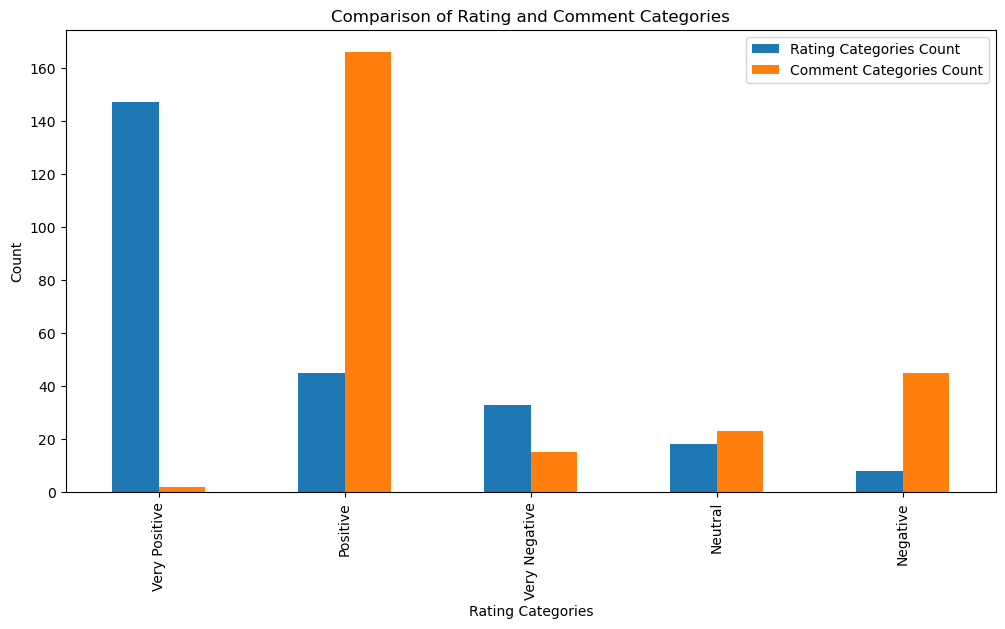

In [22]:
import matplotlib.pyplot as plt

# Create a bar plot to compare the counts of rating and comment categories
comparison.plot(kind='bar', figsize=(12, 6))

# Set labels and title
plt.xlabel('Rating Categories')
plt.ylabel('Count')
plt.title('Comparison of Rating and Comment Categories')

# Show the plot
plt.show()

In [23]:
# Get the mismatches
mismatches = df[df['Rating Categories'].str.lower() != df['Comment Categories'].str.lower()]

print(f"Mismatches found: {len(mismatches)}")

Mismatches found: 194


In [24]:
# Do mapping Rating Categories
df.loc[:,'Rating Categories'] = df['Rating Categories'].map({'Very Positive': 'Positive', 'Positive': 'Positive', 'Neutral': 'Neutral', 'Negative': 'Negative', 'Very Negative': 'Negative'}) 

In [25]:
# Do mapping Comment Categories
df.loc[:, 'Comment Categories'] = df['Comment Categories'].map({'Very Positive': 'Positive', 'Positive': 'Positive', 'Neutral': 'Neutral', 'Negative': 'Negative', 'Very Negative': 'Negative'})

In [26]:
df.isnull().sum()

Rating                0
Comments              0
Category              0
Comment Categories    0
Rating Categories     0
dtype: int64

In [27]:
# Count occurrences of each category in both columns
rating_categories_counts = df['Rating Categories'].value_counts()
comment_categories_counts = df['Comment Categories'].value_counts()

# Find common categories
common_categories = rating_categories_counts.index.intersection(comment_categories_counts.index)

# Compare counts for common categories
comparison = pd.DataFrame({
    'Rating Categories Count': rating_categories_counts[common_categories],
    'Comment Categories Count': comment_categories_counts[common_categories]
})

print(comparison)

          Rating Categories Count  Comment Categories Count
Positive                      192                       168
Negative                       41                        60
Neutral                        18                        23


In [28]:
# Get mismatches
mismatches = df[df['Rating Categories'].str.lower() != df['Comment Categories'].str.lower()]

print(f"Mismatches found: {len(mismatches)}")

Mismatches found: 53


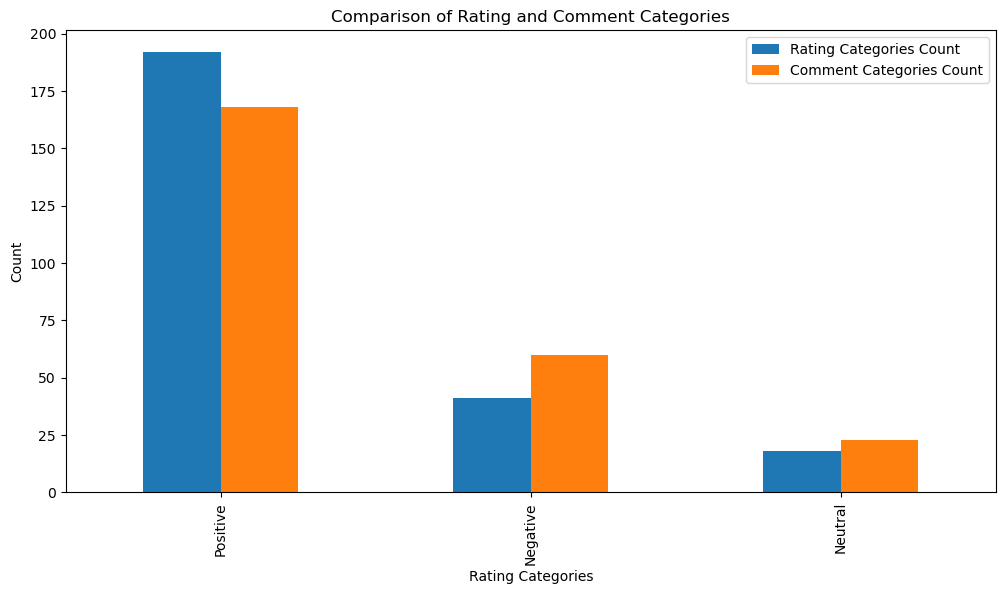

In [29]:
# Create a bar plot to compare the counts of rating and comment categories
comparison.plot(kind='bar', figsize=(12, 6))

# Set labels and title
plt.xlabel('Rating Categories')
plt.ylabel('Count')
plt.title('Comparison of Rating and Comment Categories')

# Show the plot
plt.show()

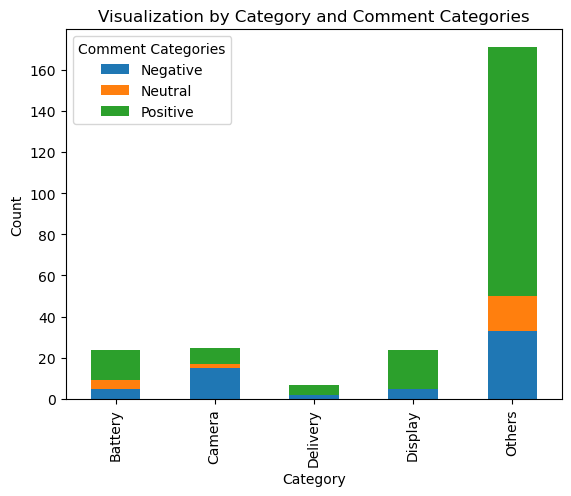

In [30]:
# Create pivot table
pivot_table = df.pivot_table(index='Category', columns='Comment Categories', aggfunc='size', fill_value=0)

# Display the pivot table
pivot_table.plot(kind='bar', stacked=True)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Visualization by Category and Comment Categories')
plt.show()